### Things that need fixing

* safe to assume we can rely on xarray skipping computations when dealing with `NaNs`?

* some non-zero values in the resulting sigmamoc calculation that may be artifact of the change of co-ords? may want to fix or wipe somehow

In [1]:
import sys, os
sys.path.append("..")
from pathlib import Path
from importlib import reload

import xarray as xr
import xnemogcm as xn
import xgcm

# gsw and gsw-xarray packages
import gsw
import gsw_xarray as xgsw

# temporary fix for the xgcm.Grid.transform deprecation warning
import warnings
warnings.filterwarnings("ignore", category=FutureWarning) 

from pyCDFTOOLS import analysis, in_out
import matplotlib.pyplot as plt
import numpy as np

In [2]:
base_dir = "/project/miffy/data/users/julian/NEMO/eORCA1_JRA55/"
data_dir = "/project/miffy/data/users/julian/NEMO/eORCA1_JRA55/GEOM/cycle1/"

# 1. Grab T files
fList_T = [fname for fname in os.listdir(data_dir) if '1m_grid_T_2015' in fname]
fList_T.sort()
fList_T = [data_dir + fname for fname in fList_T]

# 2. Grab V files
fList_V = [fname for fname in os.listdir(data_dir) if '1m_grid_V_2015' in fname]
fList_V.sort()
fList_V = [data_dir + fname for fname in fList_V]

# 3. Combine the file lists and open EVERYTHING at once
all_files = fList_T + fList_V

ds = xn.open_nemo_and_domain_cfg(
    nemo_files=all_files, 
    domcfg_files=[base_dir + "domain_cfg_cleaned.nc"]
)

# be specific and only load the cleaned one
domcfg = xn.open_domain_cfg(datadir=base_dir, files=["domain_cfg_cleaned.nc"])

In [3]:
Static_e3 = True
metrics_dict = xn.get_metrics(domcfg)
if Static_e3: # only as placeholder for completeness
    metrics_dict[('Z',)] = ['e3t_0', 'e3u_0', 'e3v_0', 'e3f_0', 'e3w_1d']
print(metrics_dict)
grid = xgcm.Grid(domcfg, metrics=metrics_dict, periodic=["X"])  # specify periodicity with a list

bd = {'boundary':'fill', 'fill_value':0}

{('X',): ['e1t', 'e1u', 'e1v', 'e1f'], ('Y',): ['e2t', 'e2u', 'e2v', 'e2f'], ('Z',): ['e3t_0', 'e3u_0', 'e3v_0', 'e3f_0', 'e3w_1d']}


In [4]:
# Rechunk the vertical dimension so it is in a single chunk
ds = ds.chunk({"z_c": -1})
grid = xgcm.Grid(ds, periodic=False)

In [5]:
# test conversion into sigma2
ds["sigma2"] = xgsw.sigma2(SA=ds["so_abs"], CT=ds["thetao_con"])

In [6]:
ds["sigma2"][0, :, 200, 250].values

array([31.85575098, 31.85647875, 31.8578381 , 31.85914893, 31.86098606,
       31.86221404, 31.86324965, 31.86423494, 31.86523921, 31.86616779,
       31.8670539 , 31.86786527, 31.86857545, 31.86918489, 31.86979523,
       31.87050745, 31.87131169, 31.87239073, 31.87533283, 31.92187088,
       32.16403253, 32.32708449, 32.56162004, 33.00719276, 33.74432583,
       34.58077816, 35.02099548, 35.10876791, 35.26017135, 35.2834205 ,
       35.38553306, 35.43460763, 35.49144838, 35.54359634, 35.6062476 ,
       35.67720918, 35.7540324 , 35.84145441, 35.9349137 , 36.02421352,
       36.1068029 , 36.18666071, 36.26561143, 36.34380496, 36.41984676,
       36.49407572, 36.57237552, 36.65240576, 36.72853095, 36.791576  ,
       36.83688592, 36.86799273, 36.89640897, 36.91577855, 36.9386749 ,
       36.96626955, 36.99299551, 37.01577233, 37.03520509, 37.04971203,
       37.06021473, 37.06952153, 37.07754271, 37.08419092, 37.09548244,
       37.10857122,         nan,         nan,         nan,      

In [7]:
# reload(analysis)
sigma_coord = np.linspace(26, 38, 151)
# kt = slice(0, None)  # if end=None, then takes the whole slice
kt = slice(0, None)
# voce_e3v = (ds["vo"]isel(t=kt) + ds.vo_eiv.isel(t=kt)) * ds.e3v_0
voce_e3v = ds["vo"].isel(t=kt) * ds["e3v_0"]
# call routine (vertical transform + compting + averaging in target co-ords)

# load into memory (with the .compute() calls)
sigma_moc = analysis.cdfsigmamoc(grid, ds,
                                 voce_e3v,
                                 ds.sigma2.isel(t=kt),
                                 sigma_coord,
                                 disp=False).compute()

voce_eiv_e3v = ds["vo_eiv"].isel(t=kt) * ds["e3v_0"]
sigma_eiv_moc = analysis.cdfsigmamoc(grid, ds, 
                                     voce_eiv_e3v, 
                                     ds.sigma2.isel(t=kt),
                                     sigma_coord,
                                     disp=False).compute()

routine can be costly and a bit slow, have disp=True to display some progress
 
routine can be costly and a bit slow, have disp=True to display some progress
 


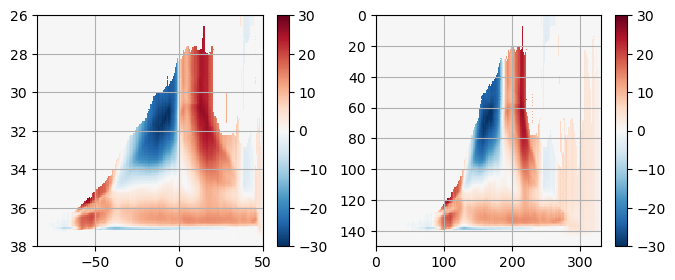

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3))
cs = axs[0].pcolor(sigma_moc.gphiv, sigma_moc.sigma, sigma_moc, cmap="RdBu_r", vmin=-30, vmax=30)
cbar = plt.colorbar(cs)
axs[0].invert_yaxis()
axs[0].grid()

cs = axs[1].pcolor(sigma_moc, cmap="RdBu_r", vmin=-30, vmax=30)
cbar = plt.colorbar(cs)
axs[1].invert_yaxis()
axs[1].grid()

In [11]:
# load these into memory
sigma_moc[:, 250].values

array([-3.45719222e+00, -3.45806295e+00, -3.46017063e+00, -3.46284389e+00,
       -3.46573551e+00, -3.46884159e+00, -3.47211254e+00, -3.47264961e+00,
       -3.47915498e+00, -3.48664365e+00, -3.49380399e+00, -3.50144547e+00,
       -3.51191770e+00, -3.43592776e+00, -4.33390918e+00, -4.12029840e+00,
       -3.63281409e+00, -3.47355346e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  

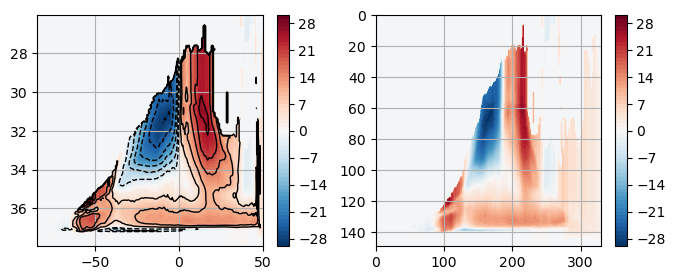

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3))
cs = axs[0].contourf(sigma_moc.gphiv, sigma_moc.sigma, sigma_moc, cmap="RdBu_r", levels=np.linspace(-30, 30, 61))
cbar = plt.colorbar(cs)
axs[0].contour(sigma_moc.gphiv, sigma_moc.sigma, sigma_moc, levels=np.concatenate([np.arange(-30,0,5),np.arange(5,35,5)]),
               colors='k', linewidths=1)
axs[0].invert_yaxis()
axs[0].grid()

cs = axs[1].contourf(sigma_moc, cmap="RdBu_r", levels=np.linspace(-30, 30, 61))
cbar = plt.colorbar(cs)
axs[1].invert_yaxis()
axs[1].grid()

In [27]:
sigma_moc.t

<xarray.DataArray 't' ()> Size: 8B
array('2015-01-16T12:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time_centered  datetime64[ns] 8B dask.array<chunksize=(), meta=np.ndarray>
    t              datetime64[ns] 8B 2015-01-16T12:00:00
    x_c            int64 8B 1
Attributes:
    axis:           T
    standard_name:  time
    long_name:      Time axis
    time_origin:    1900-01-01 00:00:00
    bounds:         t_bounds

Some values "outside" that shouldn't be there, and when accumulating ends up being big?

In [17]:
kt = slice(0, 1)
voce_e3v = ds["vo"].isel(t=kt) * ds["e3v_0"]

disp = True
method = "conservative"

sigma = ds.sigma2.isel(t=kt)
sigma_coord = np.linspace(29, 38, 91)

coords = {"X": {"right" : "x_f", "center":"x_c"},   # xU > xT
          "Y": {"right" : "y_f", "center":"y_c"},   # yV > yT
          "Z": {"center": "z_c", "outer" :"z_f"},
          "T": {"center": "t"},
         }
grid = xgcm.Grid(ds, coords=coords, metrics=xn.get_metrics(ds), periodic=False, autoparse_metadata=False)

# 1) put out some useful numbers
nt = voce_e3v.t.size # should have a t variable even if da has no t-dim

kt = 0
sigma_var = grid.interp(sigma.isel(t=kt), ['Y'], boundary='extend')
v_trans = (voce_e3v * ds.vmask).isel(t=kt, z_c=slice(0, -1))
# v_trans = v_trans.fillna(0.).rename('v_trans')  ### SURE YOU WANT TO DO THIS?
v_trans = v_trans.rename('v_trans')

v_trans_sigma  = analysis.cdfz2sig(grid, ds,
                          v_trans,
                          sigma_var.isel(z_c=slice(0, -1)),
                          sigma_coord,
                          method=method, **bd) / nt

In [18]:
v_trans[:, 100, 100].values

array([ 0.03520612,  0.03821407,  0.04203895,  0.04650152,  0.0518185 ,
        0.05818564,  0.06582779,  0.0750111 ,  0.08600758,  0.09896089,
        0.11392336,  0.13072308,  0.14890538,  0.167785  ,  0.18648616,
        0.2038148 ,  0.21806681,  0.22669665,  0.22579236,  0.20714545,
        0.17084151,  0.15252034,  0.1629731 ,  0.17311492,  0.18380217,
        0.19872377,  0.21542627,  0.23369694,  0.2542601 ,  0.27757241,
        0.30426022,  0.33502442,  0.36998475,  0.40865015,  0.44890517,
        0.48526588,  0.5242641 ,  0.57089609,  0.6009937 ,  0.63755232,
        0.67530224,  0.6934828 ,  0.70738349,  0.68290905,  0.66230077,
        0.55038632,  0.58191251,  0.42320529,  0.39479987,  0.30520625,
        0.19494372,  0.10968796,  0.04741108, -0.03954225, -0.12196107,
       -0.20299399, -0.29042245, -0.39099155, -0.47290948, -0.53540396,
       -0.60133593, -0.74750926, -0.74872354, -0.81281558, -0.87557549,
       -0.87647402, -0.92753736, -1.04476719, -1.1518898 , -1.08

In [12]:
v_trans_sigma.shape

(90, 331, 360)

In [32]:
sigma_moc = (v_trans_sigma * ds.e1v).sum(dim="x_c") / 1e6
sigma_moc.shape

(90, 331)

In [33]:
sigma_moc[:, 100].values

array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.03793165,  0.81015764,  2.49618182,  2.30125198,  0.44

In [34]:
sigma_mask = sigma_moc.copy(deep=True)
sigma_mask = sigma_mask.where(sigma_mask != 0, 0)
sigma_mask[:, 100].values

array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.03793165,  0.81015764,  2.49618182,  2.30125198,  0.44

In [35]:
sigma_moc = sigma_moc.isel(sigma=slice(None, None, -1))
sigma_moc = sigma_moc.cumsum("sigma", skipna=True)
sigma_moc = sigma_moc.isel(sigma=slice(None, None, -1))
sigma_moc = sigma_moc.where(sigma_mask != 0, 0.0)  # set to zero

In [36]:
sigma_moc[:, 100].values

array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        2.35848313,  2.32055148,  1.51039384, -0.98578798, -3.28

sign issue in both moc and sigmamoc?

* flipping array but not flipping the metric is going to screw things up!

In [22]:
moc = (voce_e3v * ds.e1v * ds.vmask).sum(dim="x_c")

    # 2) reverse the array then cumulative sum in k (i.e. from bottom)
    #    sum in Z puts it onto z_f, units of Sv
    #    then flip it back
    # moc = grid.cumsum(moc.isel(z_c=slice(None, None, -1)), axis="Z", **bd) / 1e6

In [23]:
grid.cumsum(moc[0, :, 100], axis="Z", **bd).values / 1e6

array([ 0.        ,  0.34620309,  0.72226221,  1.13374179,  1.58329879,
        2.07586831,  2.61806248,  3.21780856,  3.88402883,  4.62597528,
        5.45186832,  6.36735248,  7.37332569,  8.46396253,  9.62586975,
       10.83505256, 12.05242719, 13.22124486, 14.26688399, 15.11338281,
       15.70691369, 16.03541384, 16.15409423, 16.16510987, 16.12230838,
       16.05370032, 15.97972931, 15.91932779, 15.87530906, 15.87099072,
       15.90871623, 15.95484052, 15.99216872, 16.0565237 , 16.13361261,
       16.20816528, 16.26488445, 16.30680022, 16.3515574 , 16.36742494,
       16.38095201, 16.32455534, 16.26885567, 16.22822056, 16.1830619 ,
       16.11246659, 16.05121028, 16.01764128, 15.97879673, 15.96254246,
       15.9175668 , 15.90572679, 15.67846581, 15.44297685, 15.24085762,
       14.84681296, 14.37558374, 13.67985992, 12.83656418, 11.81843623,
       10.35734618,  8.24707856,  5.87716774,  3.35382138,  2.63803554,
        2.32149665,  2.45746944,  2.08916139,  1.2161154 ,  1.00

In [24]:
grid.cumsum(moc.isel(z_c=slice(None, None, -1))[0, :, 100], axis="Z", **bd).values / 1e6

array([  0.        ,   0.        ,   0.11225569,   0.24720454,
         0.7329315 ,   1.11523218,   1.35326194,   1.14236773,
         0.26932174,  -0.09898631,   0.03698649,  -0.27955241,
        -0.99533825,  -3.51868461,  -5.88859542,  -7.99886305,
        -9.45995309, -10.47808105, -11.32137679, -12.01710061,
       -12.48832983, -12.88237448, -13.08449372, -13.31998268,
       -13.54724366, -13.55908367, -13.60405933, -13.62031359,
       -13.65915815, -13.69272714, -13.75398345, -13.82457877,
       -13.86973743, -13.91037253, -13.96607221, -14.02246888,
       -14.00894181, -13.99307427, -13.94831708, -13.90640132,
       -13.84968215, -13.77512948, -13.69804057, -13.63368559,
       -13.59635739, -13.5502331 , -13.51250759, -13.51682593,
       -13.56084466, -13.62124618, -13.69521718, -13.76382525,
       -13.80662673, -13.79561109, -13.67693071, -13.34843056,
       -12.75489968, -11.90840086, -10.86276173,  -9.69394406,
        -8.47656943,  -7.26738662,  -6.1054794 ,  -5.01

In [44]:
dum_1 = -np.cumsum(moc[0, ::-1, 100].values)[::-1] / 1e6  # this should have a minus sign
dum_1

array([-2.35848313, -2.01228004, -1.63622092, -1.22474135, -0.77518434,
       -0.28261482,  0.25957935,  0.85932543,  1.5255457 ,  2.26749215,
        3.09338519,  4.00886934,  5.01484256,  6.1054794 ,  7.26738662,
        8.47656943,  9.69394406, 10.86276173, 11.90840086, 12.75489968,
       13.34843056, 13.67693071, 13.79561109, 13.80662673, 13.76382525,
       13.69521718, 13.62124618, 13.56084466, 13.51682593, 13.51250759,
       13.5502331 , 13.59635739, 13.63368559, 13.69804057, 13.77512948,
       13.84968215, 13.90640132, 13.94831708, 13.99307427, 14.00894181,
       14.02246888, 13.96607221, 13.91037253, 13.86973743, 13.82457877,
       13.75398345, 13.69272714, 13.65915815, 13.62031359, 13.60405933,
       13.55908367, 13.54724366, 13.31998268, 13.08449372, 12.88237448,
       12.48832983, 12.01710061, 11.32137679, 10.47808105,  9.45995309,
        7.99886305,  5.88859542,  3.51868461,  0.99533825,  0.27955241,
       -0.03698649,  0.09898631, -0.26932174, -1.14236773, -1.35

In [45]:
dum_2 = (np.cumsum(moc[0, :, 100].values) - np.sum(moc[0, :, 100].values)) / 1e6  # this one does an extra operation
dum_2

array([-2.01228004e+00, -1.63622092e+00, -1.22474135e+00, -7.75184337e-01,
       -2.82614823e-01,  2.59579351e-01,  8.59325428e-01,  1.52554570e+00,
        2.26749215e+00,  3.09338519e+00,  4.00886934e+00,  5.01484256e+00,
        6.10547940e+00,  7.26738662e+00,  8.47656943e+00,  9.69394406e+00,
        1.08627617e+01,  1.19084009e+01,  1.27548997e+01,  1.33484306e+01,
        1.36769307e+01,  1.37956111e+01,  1.38066267e+01,  1.37638252e+01,
        1.36952172e+01,  1.36212462e+01,  1.35608447e+01,  1.35168259e+01,
        1.35125076e+01,  1.35502331e+01,  1.35963574e+01,  1.36336856e+01,
        1.36980406e+01,  1.37751295e+01,  1.38496822e+01,  1.39064013e+01,
        1.39483171e+01,  1.39930743e+01,  1.40089418e+01,  1.40224689e+01,
        1.39660722e+01,  1.39103725e+01,  1.38697374e+01,  1.38245788e+01,
        1.37539835e+01,  1.36927271e+01,  1.36591581e+01,  1.36203136e+01,
        1.36040593e+01,  1.35590837e+01,  1.35472437e+01,  1.33199827e+01,
        1.30844937e+01,  

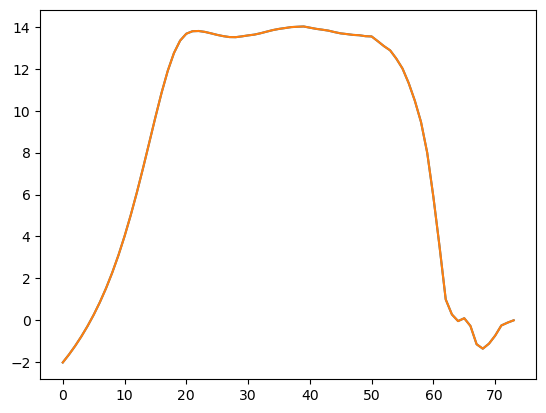

In [47]:
plt.plot(dum_1[1::])
plt.plot(dum_2[:-1])